El objetivo de este notebook es realizar un Análisis Exploratorio de Datos (Exploratory Data Analysis, EDA) sobre el conjunto de datos seleccionado con el fin de comprender su estructura, evaluar su calidad e identificar patrones relevantes dentro de la información disponible.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("Online _Retail_Data.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

Tipos de dato de cada columna.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Estasdisticas preeliminares.

In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Verifico existencia de datos nulos.

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Muestra todos los pedidos con cancelaciones. Donde la columa "InvoiceNo" empezara con C en caso de haber sido cancelada la venta.

In [8]:
cancelaciones = df[df["InvoiceNo"].str.startswith("C", na=False)]
cancelaciones

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01/12/2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01/12/2010 09:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01/12/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01/12/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,01/12/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,09/12/2011 09:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,09/12/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,09/12/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,09/12/2011 11:58,1.25,17315.0,United Kingdom


Reenombro el dataset con los datos sin cancelaciones.

In [9]:
# df sin pedidos cancelados
df_sincal = df[~df["InvoiceNo"].str.startswith("C", na=False)]
df_sincal

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2011 12:50,4.15,12680.0,France


Dataset para el Dashboard en PowerBI

In [48]:
df_sincal.to_csv("df__sincal_limpio", index=False, encoding="utf-8")

Revisamos existencia de datos negativos en las columnas de Quantity y UnitPrice

In [ ]:
print("Registros con quantity < 0: ", (df_sincal["Quantity"] < 0).sum()) # Imprime cuantos datos de Quantity son negativos
print("Registros con UnitPrice < 0: ", (df["UnitPrice"] < 0).sum()) # Imprime cuantos datos de UnitPrice son negativos

Registros con quantity < 0:  1336
Registros con UnitPrice < 0:  2


Se hace la limpieza del dataset para obtener las ventas reales.



In [ ]:
df_sincal["Description"] = df_sincal["Description"].fillna("Sin descripción") # Rellena descripciones faltantes
df_sincal = df_sincal.dropna(subset=["CustomerID"]) # Borra los CustomerID invalidos
df_sincal = df_sincal[df_sincal["Quantity"] > 0] # Elimina Quantity negativas
df_sincal = df_sincal[df_sincal["UnitPrice"] > 0] # Elimina UnitPrice negativas o 0
df_sincal["InvoiceDate"]=pd.to_datetime(df_sincal["InvoiceDate"], dayfirst=True, errors="coerce") # Convierte la columna de "InvoiceDate" a formato fecha


df_sincal.isnull().sum()

C:\Users\luise\AppData\Local\Temp\ipykernel_21048\3706750312.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sincal["Description"] = df_sincal["Description"].fillna("Sin descripción") # Rellena descripciones faltantes


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Defino la columna de ingresos totales por venta

In [ ]:
df_sincal["Income"] = df_sincal["UnitPrice"] * df_sincal["Quantity"]  # precio unitario * cantidad = ingreso

df_sincal.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Income
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
ingresos_promedio = df_sincal["Income"].mean() # Promedio de ingresos totales
ingresos_totales = df_sincal["Income"].sum() # Ingresos totales


print("Los ingresos totales son: ", ingresos_totales)
print("El promedio de ingresos totales es: ", ingresos_promedio)

Los ingresos totales son:  8911407.904
El promedio de ingresos totales es:  22.396999889415003


Grafica de Ingresos Totales por Papis

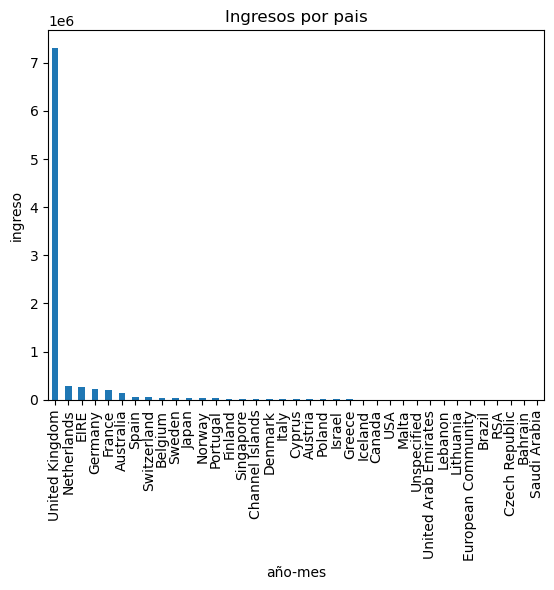

In [ ]:
ingreso_por_pais = df_sincal.groupby("Country")["Income"].sum() # Total ingresos por país

ingreso_por_pais.sort_values(ascending=False).plot(kind="bar")

plt.title("Ingresos por pais")
plt.xlabel("año-mes")
plt.ylabel("ingreso")

plt.show()

Gráfica de Ingresos Totales por Mes

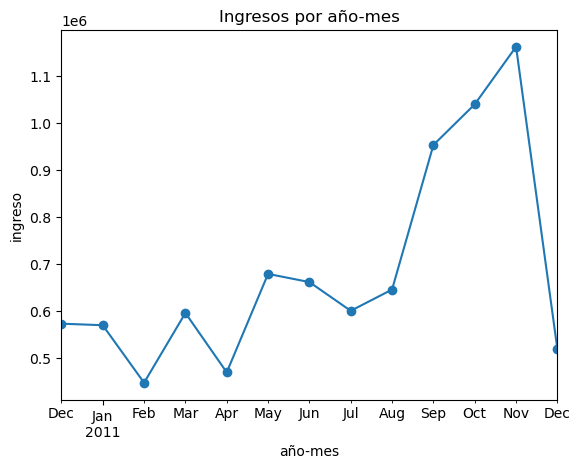

In [ ]:

df_sincal["YearMonth"] = df_sincal["InvoiceDate"].dt.to_period("M") # Creamos la columa YearMonth para crear la gráftica por mes
ingreso_por_mes_año = df_sincal.groupby("YearMonth")["Income"].sum() # Total de ingresos por mes

ingreso_por_mes_año.plot(kind="line", marker="o")

plt.title("Ingresos por año-mes")
plt.xlabel("año-mes")
plt.ylabel("ingreso")

plt.show()

TICKET PROMEDIO

In [16]:
ticket_promedio = df_sincal['Income'].sum() / df_sincal['InvoiceNo'].nunique()

print(ticket_promedio)

480.8659563997409


Venta mayor y menor

In [30]:
venta_mayor = df_sincal["Income"].max()
venta_menor = df_sincal["Income"].min()

print("Monto mayor de venta: ", venta_mayor)
print("Monto menor de venta: ", venta_menor)


Monto mayor de venta:  168469.6
Monto menor de venta:  0.001


Definimos el gasto por cliente para revisar estadisticas

In [40]:
gasto_cliente = df_sincal.groupby("CustomerID")["Income"].sum()

gasto_cliente.describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: Income, dtype: float64

Clientes que mas y menos ingresos generaron.

In [ ]:
cliente_mas_ingreso = df_sincal.groupby("CustomerID")["Income"].sum().max()

cliente_menos_ingreso = df_sincal.groupby("CustomerID")["Income"].sum().min()

print("Cantidad de ingreso del cliente con mayor gasto: ", cliente_mas_ingreso)
print("Cantidad de ingreso del cliente con menor gasto: ", cliente_menos_ingreso)

Cantidad de ingreso del cliente con mayor gasto:  280206.02
Cantidad de ingreso del cliente con menor gasto:  3.75


Calculamos la mediana 

In [46]:
clientes_ingreso = (
    df_sincal.groupby("CustomerID")["Income"]
    .sum()
)
mediana = clientes_ingreso.median()

print(f"Mediana de ingreso por cliente: {mediana:.2f}")

Mediana de ingreso por cliente: 674.49


Realizamos un gráfico donde se muestre el cliente que menos gasto, el cliente que mas se acerca a la mediana y el cliente que mas gasto.

Cliente más cercano a la mediana: 13951.0
Ingreso: 674.45


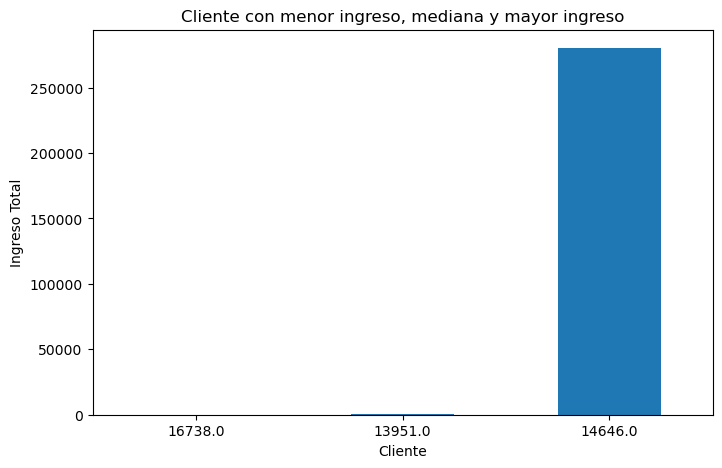

In [47]:
cliente_mediana = (clientes_ingreso - clientes_ingreso.median()).abs().idxmin()
ingreso_mediana = clientes_ingreso.loc[cliente_mediana]

print("Cliente más cercano a la mediana:", cliente_mediana)
print("Ingreso:", ingreso_mediana)

menor = clientes_ingreso.idxmin()
mayor = clientes_ingreso.idxmax()
mediano = (clientes_ingreso - clientes_ingreso.median()).abs().idxmin()

muestra = clientes_ingreso.loc[[menor, mediano, mayor]]

muestra.plot(
    kind="bar",
    figsize=(8,5),
    title="Cliente con menor ingreso, mediana y mayor ingreso"
)

plt.xlabel("Cliente")
plt.ylabel("Ingreso Total")
plt.xticks(rotation=0)
plt.show()



Nos damos cuenta que la mayoria de los clientes no generan tanto ingreso y que existen pocos clientes que generan mucho ingreso.